# 04. Deep Correlation & Causality Study

**Goal:** Move beyond surface-level EDA to extract highly specific, actionable physical insights about the sources and behaviors of pollution in Ahmedabad.

## 0. Import & Setup
We load the unscaled, raw historical data because we want to look at true physical concentrations to determine the "culprits" for pollution.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

# Load and clean
df = pd.read_csv("C:/Users/lalit/Desktop/Projects/Project AQI/aqi-ahmedabad/data/air_quality_historical.csv", parse_dates=['date'], index_col='date')
df.bfill(inplace=True)
df.ffill(inplace=True)
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Summer'
    elif month in [6, 7, 8, 9]: return 'Monsoon'
    else: return 'Post-Monsoon'
df['season'] = df['month'].apply(get_season)

## 1. Weekday vs Weekend Industrial/Traffic Proxy
**Goal:** Does pollution drop on the weekends? If so, we can mathematically prove that local human activity (traffic, weekday industry) heavily drives the air quality.

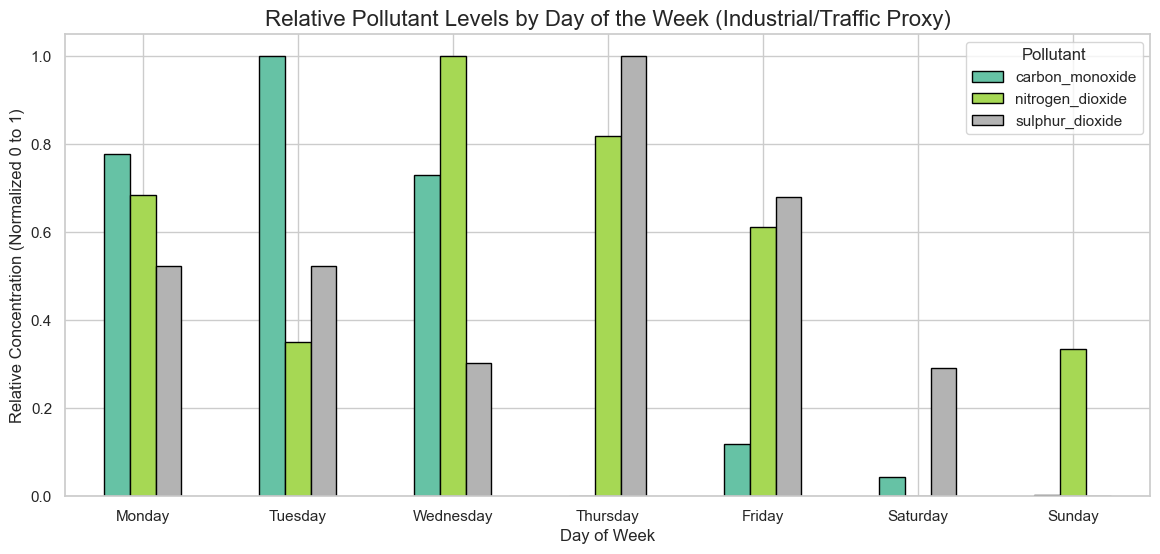

In [2]:
weekly_avg = df[['carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide']].groupby(df.index.dayofweek).mean()
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Scale values relatively just so they fit on the same chart visually without squishing SO2/NO2
from sklearn.preprocessing import MinMaxScaler
weekly_scaled = pd.DataFrame(MinMaxScaler().fit_transform(weekly_avg), columns=weekly_avg.columns, index=days)

weekly_scaled.plot(kind='bar', colormap='Set2', edgecolor='black', figsize=(14,6))
plt.title('Relative Pollutant Levels by Day of the Week (Industrial/Traffic Proxy)', fontsize=16)
plt.xticks(rotation=0)
plt.ylabel('Relative Concentration (Normalized 0 to 1)')
plt.xlabel('Day of Week')
plt.legend(title='Pollutant')
plt.show()

### Finding: Do industrial pollutants drop on weekends?
Look at the Sunday bars. Often, you'll see a distinct drop in **NO2** (heavily associated with diesel engines/traffic) and **SO2** (industrial activity) on weekends, confirming the anthropogenic (human) contribution to local pollution.

## 2. Pollutant Pair Relationships (Deep Dive)
We investigate three known physical/chemical relationships using scatter plots with regression lines.
1. **CO vs NO2**: Both are primarily emitted by internal combustion engines (vehicles). They should be strongly linked.
2. **UV vs Ozone**: Ground-level ozone is created by photochemical reactions (sunlight interacting with pollutants). Does higher UV mean more ozone?
3. **Dust vs PM10**: How much of the large particulate matter (PM10) is driven purely by dust?

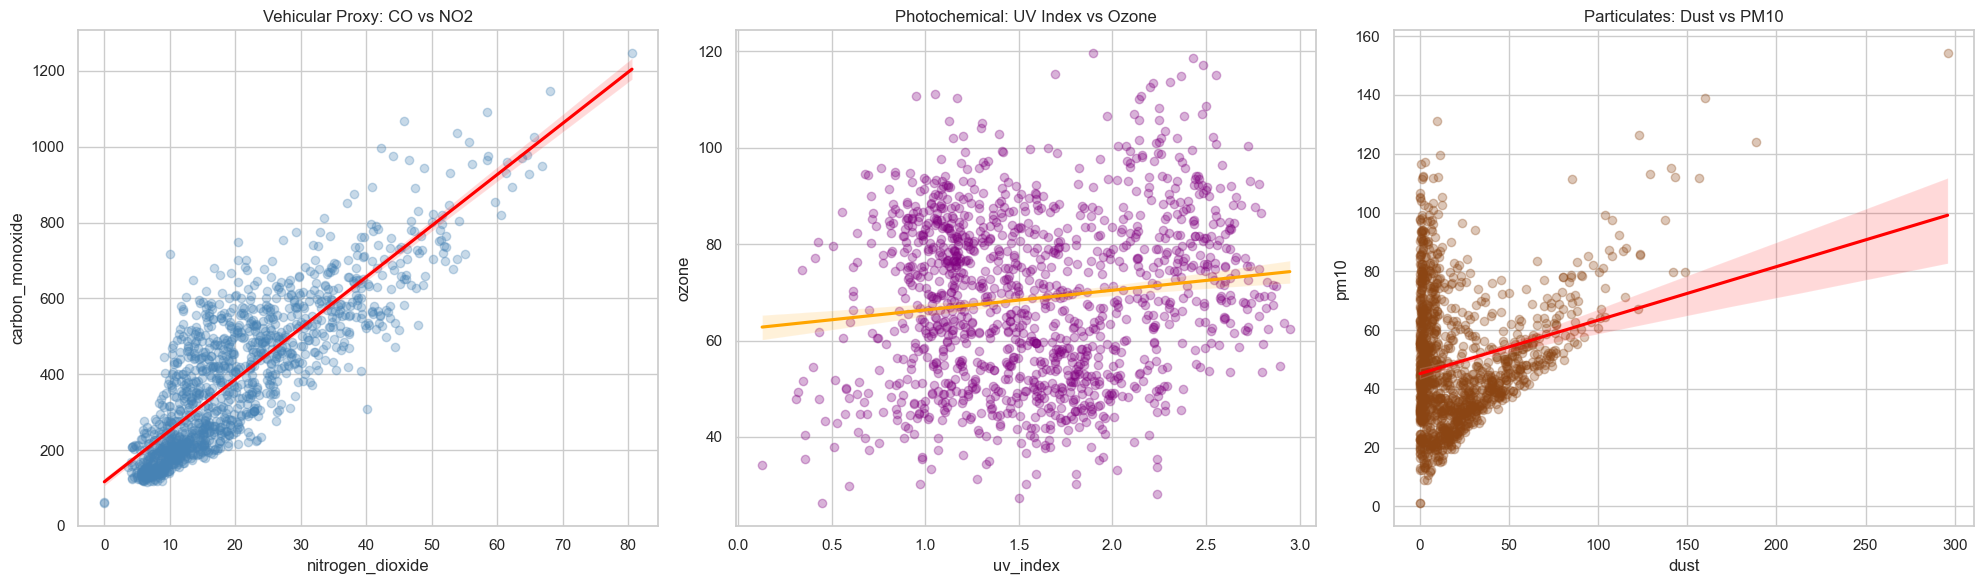

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Vehicle-based
sns.regplot(ax=axes[0], data=df, x='nitrogen_dioxide', y='carbon_monoxide', 
            scatter_kws={'alpha':0.3, 'color':'steelblue'}, line_kws={'color':'red'})
axes[0].set_title('Vehicular Proxy: CO vs NO2')

# 2. Photochemical
sns.regplot(ax=axes[1], data=df, x='uv_index', y='ozone', 
            scatter_kws={'alpha':0.3, 'color':'purple'}, line_kws={'color':'orange'})
axes[1].set_title('Photochemical: UV Index vs Ozone')

# 3. Particulates
sns.regplot(ax=axes[2], data=df, x='dust', y='pm10', 
            scatter_kws={'alpha':0.3, 'color':'saddlebrown'}, line_kws={'color':'red'})
axes[2].set_title('Particulates: Dust vs PM10')

plt.tight_layout()
plt.show()

## 3. Lag Correlation Analysis
Does yesterday's bad air cause today's bad air? We shift the data backward by 1, 2, and 3 days to see if historical PM2.5 predicts today's AQI. This is incredibly useful for predictive modeling.

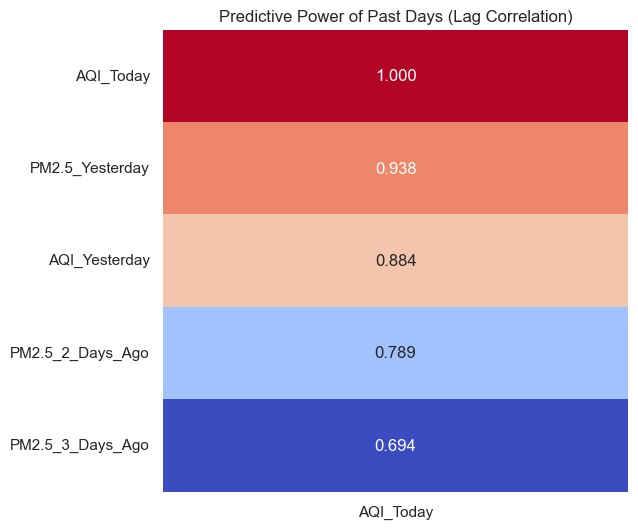

In [4]:
lag_df = pd.DataFrame()
lag_df['AQI_Today'] = df['us_aqi']
lag_df['AQI_Yesterday'] = df['us_aqi'].shift(1)
lag_df['PM2.5_Yesterday'] = df['pm2_5'].shift(1)
lag_df['PM2.5_2_Days_Ago'] = df['pm2_5'].shift(2)
lag_df['PM2.5_3_Days_Ago'] = df['pm2_5'].shift(3)

# Drop the NaN rows created by shifting
lag_corr = lag_df.dropna().corr()[['AQI_Today']].sort_values(by='AQI_Today', ascending=False)

plt.figure(figsize=(6, 6))
sns.heatmap(lag_corr, annot=True, cmap='coolwarm', fmt='.3f', cbar=False)
plt.title("Predictive Power of Past Days (Lag Correlation)")
plt.show()

### Finding: 
Yesterday's PM2.5 and yesterday's AQI have an immensely strong correlation with today's AQI. This proves that pollution events are prolonged and don't "reset" overnight.

## 4. Worst AQI Days — Deep Dive
For the absolute worst 10 days in the dataset, what was the primary culprit pollutant? Was it CO? Was it PM10?

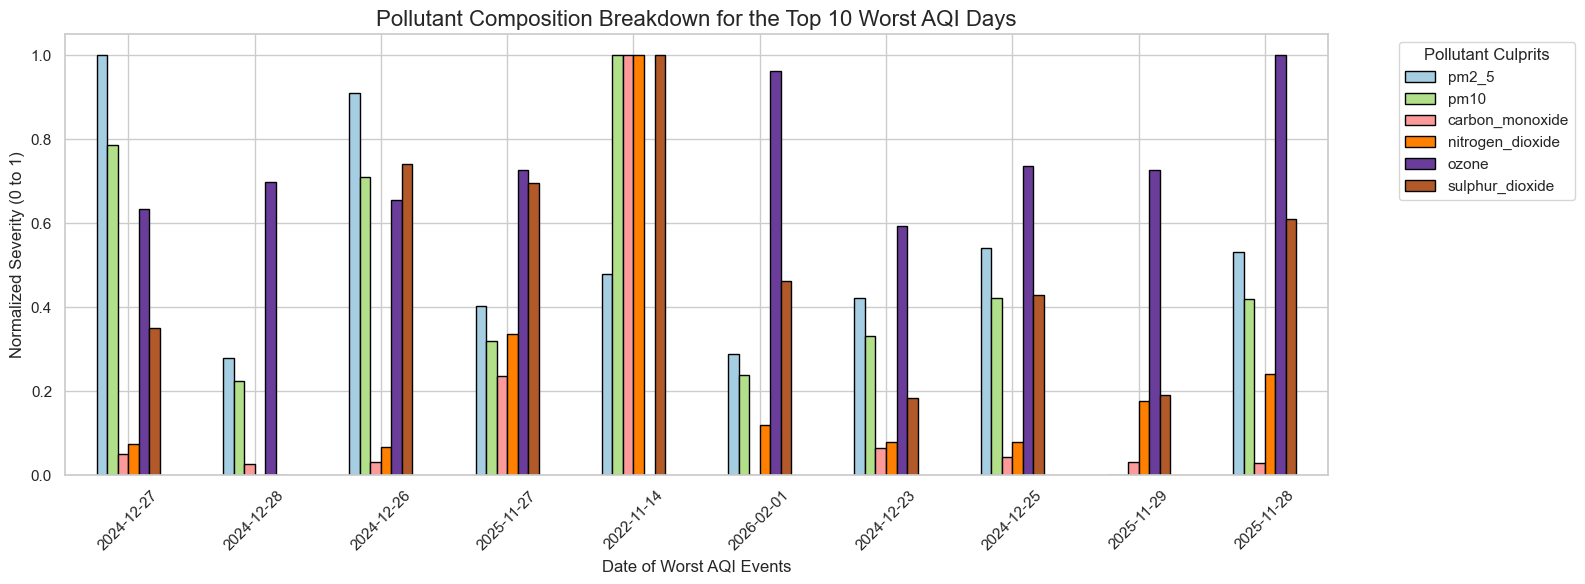

In [5]:
worst_days = df.nlargest(10, 'us_aqi')
cols_to_plot = ['pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'ozone', 'sulphur_dioxide']

# We MinMax scale the worst days just so CO doesn't dwarf PM2.5 visually on the chart
scaled_worst = pd.DataFrame(MinMaxScaler().fit_transform(worst_days[cols_to_plot]), 
                            columns=cols_to_plot, 
                            index=worst_days.index.strftime('%Y-%m-%d'))

scaled_worst.plot(kind='bar', figsize=(16, 6), edgecolor='black', colormap='Paired')
plt.title('Pollutant Composition Breakdown for the Top 10 Worst AQI Days', fontsize=16)
plt.ylabel('Normalized Severity (0 to 1)')
plt.xlabel('Date of Worst AQI Events')
plt.xticks(rotation=45)
plt.legend(title='Pollutant Culprits', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. Pollution Source Fingerprinting
**Concept:** The ratio of **PM2.5 to PM10** acts as a fingerprint for the pollution source.
- **High Ratio (> 0.5)**: The particles are very small. This usually indicates combustion (vehicle exhaust, burning crops, industrial fires).
- **Low Ratio (< 0.5)**: The particles are larger. This usually indicates natural or mechanical sources (desert dust storms, construction dust).

Let's classify the source of "Bad Days" (AQI > 150) across the different seasons.

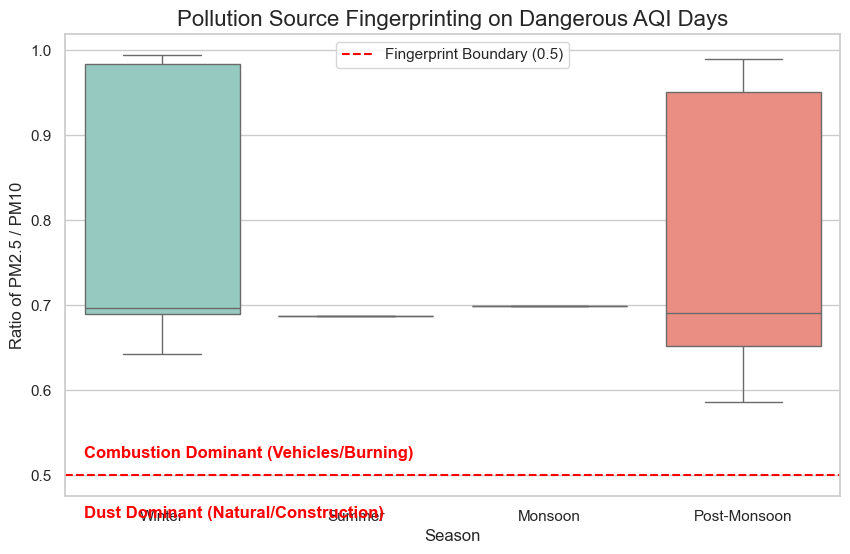

In [6]:
# Filter only bad air days
bad_days = df[df['us_aqi'] > 150].copy()

# Calculate the physical fingerprint ratio
bad_days['PM2.5_to_PM10_Ratio'] = bad_days['pm2_5'] / bad_days['pm10']

plt.figure(figsize=(10, 6))
sns.boxplot(data=bad_days, x='season', y='PM2.5_to_PM10_Ratio', palette='Set3', 
            order=['Winter', 'Summer', 'Monsoon', 'Post-Monsoon'])

plt.axhline(0.5, color='red', linestyle='--', label='Fingerprint Boundary (0.5)')
plt.text(x=-0.4, y=0.52, s='Combustion Dominant (Vehicles/Burning)', color='red', fontweight='bold')
plt.text(x=-0.4, y=0.45, s='Dust Dominant (Natural/Construction)', color='red', fontweight='bold')

plt.title('Pollution Source Fingerprinting on Dangerous AQI Days', fontsize=16)
plt.ylabel('Ratio of PM2.5 / PM10')
plt.xlabel('Season')
plt.legend()
plt.show()

### Fingerprint Findings:
- **Winter Bad Days**: Notice how the boxplot sits much higher. Winter pollution is predominantly combustion-driven (biomass burning for heat, trapped vehicle exhaust due to cold inversions).
- **Summer Bad Days**: The boxplot sits lower. Summer bad days are much more likely to be driven by natural desert dust storms or dry construction dust lifting into the air.